This is an example of loading a monolithic NetCDF file containing all bursts from a deployment. Other functionality demonstrated:

- Specifying a `lambda` function in `name_map` to transform multiple input variables into a single `time` variable
- Specifying `lambda` functions in `name_map` to convert velocity from mm/s to m/s
- Forwarding `decode_times=False` to the data loader
- Specifying a transformation matrix string key in `name_map` rather than passing in the matrix to the preprocessing opts

The source dataset is too large to commit, but it can be downloaded [here](https://www.sciencebase.gov/catalog/item/602a99fad34eb1203113b18a)

In [1]:
from pytoast.ocean.adcp import ADCP
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
adcp = ADCP(
    files="CSF20_Channel_Time_Series/CSF20CHT01sig-b.nc",
    name_map={
        "time": lambda x: x["time"] + x["time2"] / 86400000,
        "u1": lambda x: x["vel1_1277"] / 1000,
        "u2": lambda x: x["vel2_1278"] / 1000,
        "u3": lambda x: x["vel3_1279"] / 1000,
        "u4": lambda x: x["vel4_1280"] / 1000,
        "z": "depth",
        "transformation_matrix": "TransMatrix"
    },
    burst_dim="time",  # This ds.dims["time"] which encodes the 332 bursts, as opposed to the data vars ds["time"] and ds["time2"]
    orientation="up",
    manufacturer="nortek",
    z_convention="depth",
    decode_times=False
)

In [3]:
# Preprocessing opts to rotate. No transformation matrix necessary because it was specified in name_map.
pre_opts = {
    "rotate": {
        "coords_out": "xyz",
        "flow_rotation": "align_streamwise",
    },
}
adcp.set_preprocess_opts(pre_opts)

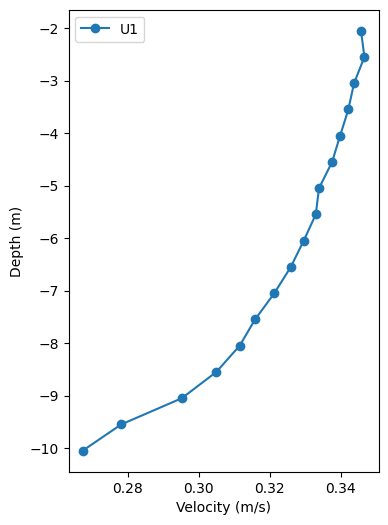

In [4]:
# Plotting a mean velocity profile
burst = adcp.load_burst(5)

# In this dataset's convention, depth is positive m below the mean surface. Here we restrict
# to values below the noise-contaminated surface region
mask = (adcp.z > 1.75)

fig, ax = plt.subplots(figsize=(4, 6))
ax.plot(np.mean(burst["u1"][mask, :], axis=1), -adcp.z[mask], 'o-', label="U1")
ax.set_xlabel("Velocity (m/s)")
ax.set_ylabel("Depth (m)")
ax.legend()